=============================================================================
HYBRID QUANTUM-CLASSICAL FEATURE EXTRACTION + QSVM
Reproduccion experimental completa para Google Colab
Basado en: "Hybrid Quantum-Classical Feature Extraction approach for
           Image Classification using Autoencoders and Quantum SVMs" (2024)

=============================================================================

In [1]:
# =============================================================================
# CELDA 1: INSTALACION DE DEPENDENCIAS
# =============================================================================
# Instalar dependencias (ejecutar una sola vez)

# Instalar PyTorch con CUDA
!pip install -q torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118

# Instalar PennyLane (framework cuantico principal)
!pip install -q pennylane

# Instalar Qiskit (framework cuantico secundario)
!pip install -q qiskit qiskit-machine-learning qiskit-aer

# Instalar librerias clasicas
!pip install -q scikit-learn matplotlib seaborn pandas numpy scipy

# Instalar UMAP para visualizacion de embeddings
!pip install -q umap-learn

print("[OK] Todas las dependencias instaladas correctamente")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 50.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 937.5/937.5 kB 16.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.5/25.5 MB 47.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 57.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.2/167.2 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 69.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 95.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 263.1/263.1 kB 27.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 126.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 5.4 MB/s eta 0:00:00
[OK] Todas las dependencias instaladas correctamente


In [2]:
# =============================================================================
# CELDA 2: DETECCION DE HARDWARE
# =============================================================================
# Detectar GPU y hardware disponible

import torch
import platform
import psutil
import time
import os
import sys
import json
import warnings
warnings.filterwarnings('ignore')

print("=" * 60)
print("INFORME DE HARDWARE - Google Colab")
print("=" * 60)

gpu_available = torch.cuda.is_available()
if gpu_available:
    gpu_name = torch.cuda.get_device_name(0)
    gpu_memory = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"GPU: {gpu_name}")
    print(f"Memoria GPU: {gpu_memory:.2f} GB")
    device = torch.device("cuda")
    print(f"Device: CUDA")
else:
    print("GPU: NO DISPONIBLE (usando CPU)")
    device = torch.device("cpu")

print(f"CPU: {platform.processor()}")
print(f"Nucleos: {psutil.cpu_count(logical=True)}")
print(f"RAM: {psutil.virtual_memory().total / 1e9:.2f} GB")
print(f"Sistema: {platform.system()} {platform.release()}")
print(f"PyTorch: {torch.__version__}")

import pennylane as qml
print(f"PennyLane: {qml.__version__}")

import sklearn
print(f"scikit-learn: {sklearn.__version__}")

import qiskit
print(f"Qiskit: {qiskit.__version__}")

print("=" * 60)

DEVICE = device
USE_GPU = gpu_available

INFORME DE HARDWARE - Google Colab
GPU: Tesla T4
Memoria GPU: 15.64 GB
Device: CUDA
CPU: x86_64
Nucleos: 2
RAM: 13.61 GB
Sistema: Linux 6.6.122+
PyTorch: 2.11.0+cu128
PennyLane: 0.45.0
scikit-learn: 1.6.1
Qiskit: 2.4.2


In [3]:
# =============================================================================
# CELDA 3: CONFIGURACION GLOBAL Y SEMILLAS
# =============================================================================
# Configurar experimento

import numpy as np
import random

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

class Config:
    # Dataset
    DATASET = "MNIST"
    NUM_CLASSES = 10
    BINARY_CLASSES = [0, 1]

    # Autoencoder
    AE_LATENT_DIM = 64
    AE_EPOCHS = 20
    AE_BATCH_SIZE = 128
    AE_LEARNING_RATE = 1e-3

    # PCA
    PCA_COMPONENTS = 4

    # QSVM (NISQ: pocas muestras, pocos qubits)
    N_QUBITS = 4
    QSVM_TRAIN_SIZE = 100
    QSVM_TEST_SIZE = 50
    QKERNEL_REPS = 2

    # SVM clasico
    SVM_C = 1.0
    SVM_KERNEL = "rbf"

    # Paths
    OUTPUT_DIR = "/content/hybrid_qml_results"
    MODELS_DIR = f"{OUTPUT_DIR}/models"
    METRICS_DIR = f"{OUTPUT_DIR}/metrics"
    PLOTS_DIR = f"{OUTPUT_DIR}/plots"
    CSV_DIR = f"{OUTPUT_DIR}/csv"
    JSON_FILE = f"{OUTPUT_DIR}/metrics/metrics_summary.json"
    README_FILE = f"{OUTPUT_DIR}/README.md"

config = Config()

print(f"Dataset: {config.DATASET}")
print(f"Latent dim (autoencoder): {config.AE_LATENT_DIM}")
print(f"Componentes PCA: {config.PCA_COMPONENTS}")
print(f"Qubits (kernel cuantico): {config.N_QUBITS}")
print(f"Muestras train QSVM: {config.QSVM_TRAIN_SIZE}")
print(f"Muestras test QSVM: {config.QSVM_TEST_SIZE}")
print(f"Device: {DEVICE}")
print(f"Seed: {SEED}")

for d in [config.MODELS_DIR, config.METRICS_DIR, config.PLOTS_DIR, config.CSV_DIR]:
    os.makedirs(d, exist_ok=True)

Dataset: MNIST
Latent dim (autoencoder): 64
Componentes PCA: 4
Qubits (kernel cuantico): 4
Muestras train QSVM: 100
Muestras test QSVM: 50
Device: cuda
Seed: 42


In [4]:
# =============================================================================
# CELDA 4: CARGA Y PREPROCESAMIENTO DE MNIST
# =============================================================================
# Cargar dataset MNIST

from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.MNIST(
    root='/content/data', train=True, download=True, transform=transform
)
test_dataset = datasets.MNIST(
    root='/content/data', train=False, download=True, transform=transform
)

print(f"Train samples: {len(train_dataset)}")
print(f"Test samples: {len(test_dataset)}")
print(f"Image shape: {train_dataset[0][0].shape}")
print(f"Num classes: {len(train_dataset.classes)}")

# Crear DataLoaders para autoencoder
train_loader = DataLoader(
    train_dataset, batch_size=config.AE_BATCH_SIZE,
    shuffle=True, num_workers=2, pin_memory=True
)
test_loader = DataLoader(
    test_dataset, batch_size=config.AE_BATCH_SIZE,
    shuffle=False, num_workers=2, pin_memory=True
)

100%|██████████| 9.91M/9.91M [00:00<00:00, 16.7MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 502kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.66MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.36MB/s]

Train samples: 60000
Test samples: 10000
Image shape: torch.Size([1, 28, 28])
Num classes: 10


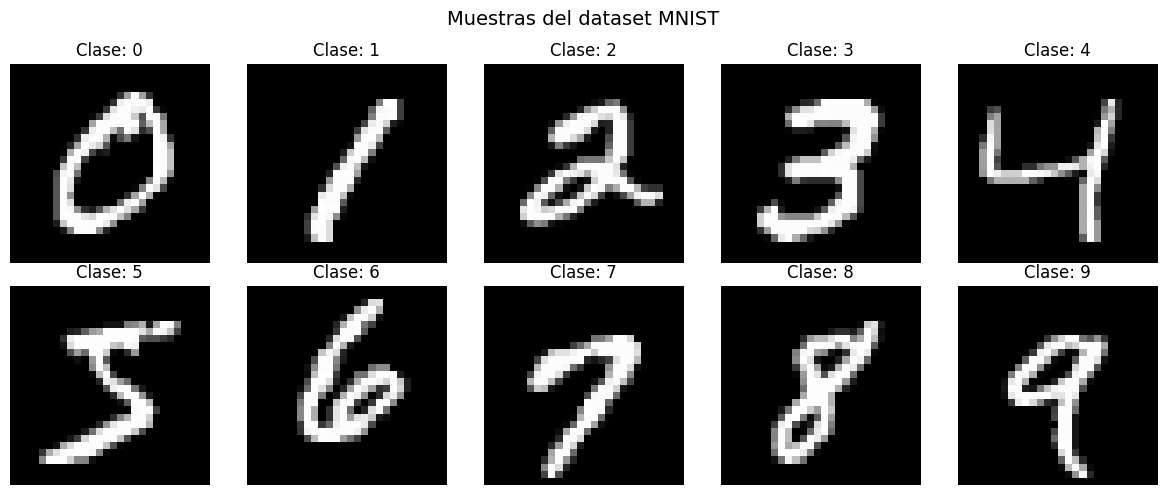

[OK] Visualizacion de muestras completada


In [5]:
# =============================================================================
# CELDA 5: VISUALIZACION DE MUESTRAS
# =============================================================================
# Visualizar muestras del dataset

import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i in range(10):
    row, col = i // 5, i % 5
    idx = (train_dataset.targets == i).nonzero(as_tuple=True)[0][0].item()
    img, label = train_dataset[idx]
    axes[row, col].imshow(img.squeeze(), cmap='gray')
    axes[row, col].set_title(f'Clase: {label}')
    axes[row, col].axis('off')
plt.suptitle('Muestras del dataset MNIST', fontsize=14)
plt.tight_layout()
plt.savefig(f'{config.PLOTS_DIR}/mnist_samples.png', dpi=150, bbox_inches='tight')
plt.show()
print("[OK] Visualizacion de muestras completada")

In [11]:
# =============================================================================
# CELDA 6: DEFINICION DEL AUTOENCODER CONVOLUCIONAL
# =============================================================================
# Definir arquitectura del autoencoder

import torch.nn as nn
import torch.nn.functional as F

class ConvEncoder(nn.Module):
    """Encoder convolucional basado en ResNet10-like (simplificado)"""
    def __init__(self, latent_dim=64):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(128, 256, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
        )
        self.fc = nn.Linear(256 * 2 * 2, latent_dim)

    def forward(self, x):
        x = self.encoder(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

class ConvDecoder(nn.Module):
    """Decoder convolucional"""
    def __init__(self, latent_dim=64):
        super().__init__()
        self.fc = nn.Linear(latent_dim, 256 * 2 * 2)
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(128, 64, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 1, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.Tanh(),
        )

    def forward(self, x):
        x = self.fc(x)
        x = x.view(x.size(0), 256, 2, 2)
        x = self.decoder(x)
        return x

class ConvAutoencoder(nn.Module):
    def __init__(self, latent_dim=64):
        super().__init__()
        self.encoder = ConvEncoder(latent_dim)
        self.decoder = ConvDecoder(latent_dim)

    def forward(self, x):
        latent = self.encoder(x)
        recon = self.decoder(latent)
        return recon, latent

def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

ae = ConvAutoencoder(latent_dim=config.AE_LATENT_DIM).to(DEVICE)
print(f"Autoencoder creado. Parametros entrenables: {count_params(ae):,}")
print(f"  Encoder params: {count_params(ae.encoder):,}")
print(f"  Decoder params: {count_params(ae.decoder):,}")
print(f"  Latent dimension: {config.AE_LATENT_DIM}")

Autoencoder creado. Parametros entrenables: 1,136,961
  Encoder params: 453,440
  Decoder params: 683,521
  Latent dimension: 64


In [12]:
print("Recon:", recon.shape)
print("Images:", images.shape)

Recon: torch.Size([128, 1, 16, 16])
Images: torch.Size([128, 1, 28, 28])


In [13]:
# =============================================================================
# CELDA 7: ENTRENAMIENTO DEL AUTOENCODER
# =============================================================================
# Entrenar autoencoder convolucional

from tqdm.notebook import tqdm

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(ae.parameters(), lr=config.AE_LEARNING_RATE)

train_losses = []
val_losses = []

for epoch in range(config.AE_EPOCHS):
    ae.train()
    epoch_loss = 0.0
    for batch_idx, (images, _) in enumerate(train_loader):
        images = images.to(DEVICE)
        optimizer.zero_grad()
        recon, latent = ae(images)
        loss = criterion(recon, images)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    avg_train_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # Validacion
    ae.eval()
    val_loss = 0.0
    with torch.no_grad():
        for images, _ in test_loader:
            images = images.to(DEVICE)
            recon, latent = ae(images)
            loss = criterion(recon, images)
            val_loss += loss.item()
    avg_val_loss = val_loss / len(test_loader)
    val_losses.append(avg_val_loss)

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch [{epoch+1}/{config.AE_EPOCHS}]  "
              f"Train Loss: {avg_train_loss:.6f}  "
              f"Val Loss: {avg_val_loss:.6f}")

print(f"[OK] Autoencoder entrenado. Loss final train: {train_losses[-1]:.6f}")

# Guardar modelo
torch.save(ae.state_dict(), f"{config.MODELS_DIR}/autoencoder.pth")
torch.save(ae.encoder.state_dict(), f"{config.MODELS_DIR}/encoder.pth")
print(f"[OK] Modelos guardados en {config.MODELS_DIR}/")

Epoch [1/20]  Train Loss: 0.133407  Val Loss: 0.042622
Epoch [5/20]  Train Loss: 0.017236  Val Loss: 0.016217
Epoch [10/20]  Train Loss: 0.011668  Val Loss: 0.011433
Epoch [15/20]  Train Loss: 0.009494  Val Loss: 0.009499
Epoch [20/20]  Train Loss: 0.008266  Val Loss: 0.008495
[OK] Autoencoder entrenado. Loss final train: 0.008266
[OK] Modelos guardados en /content/hybrid_qml_results/models/


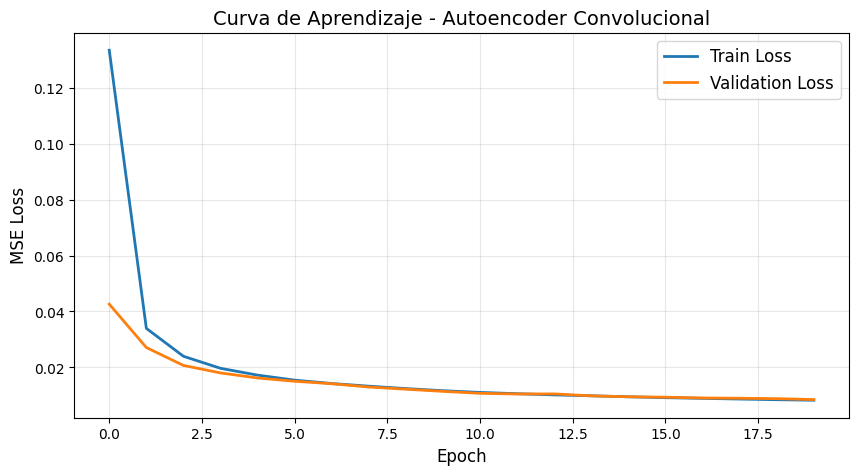

In [14]:
# =============================================================================
# CELDA 8: CURVA DE APRENDIZAJE DEL AUTOENCODER
# =============================================================================
# Graficar curva de aprendizaje del autoencoder

plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss', linewidth=2)
plt.plot(val_losses, label='Validation Loss', linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('MSE Loss', fontsize=12)
plt.title('Curva de Aprendizaje - Autoencoder Convolucional', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.savefig(f'{config.PLOTS_DIR}/autoencoder_learning_curve.png', dpi=150, bbox_inches='tight')
plt.show()

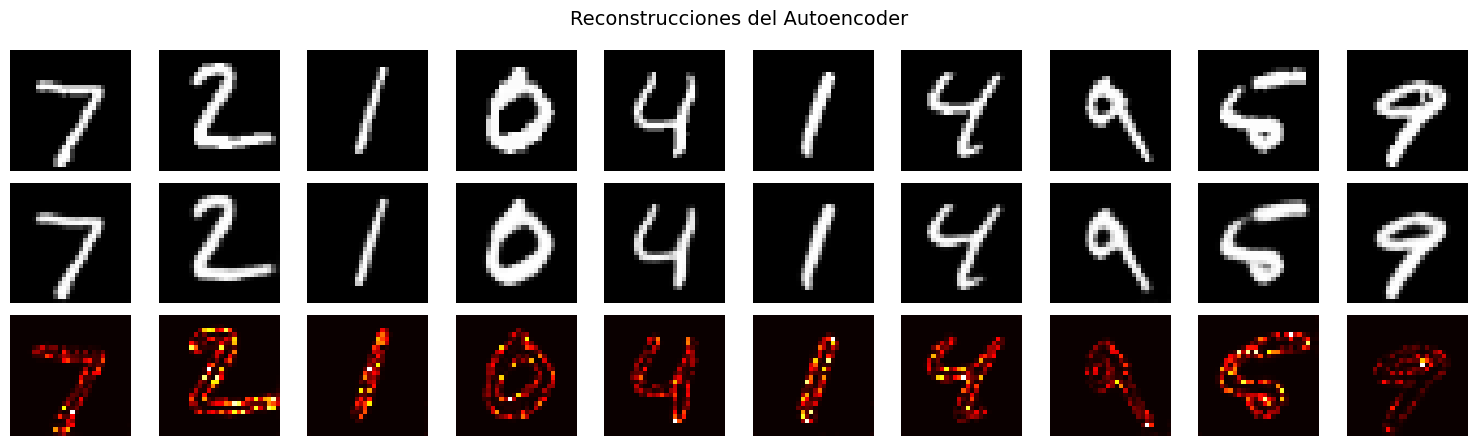

In [15]:
# =============================================================================
# CELDA 9: RECONSTRUCCION CUALITATIVA
# =============================================================================
# Visualizar reconstrucciones del autoencoder

ae.eval()
fig, axes = plt.subplots(3, 10, figsize=(15, 4.5))
sample_imgs, _ = next(iter(test_loader))
sample_imgs = sample_imgs[:10].to(DEVICE)

with torch.no_grad():
    recon, latent = ae(sample_imgs)

for i in range(10):
    axes[0, i].imshow(sample_imgs[i].cpu().squeeze(), cmap='gray')
    axes[0, i].axis('off')
    if i == 0: axes[0, i].set_ylabel('Original', fontsize=10)

    axes[1, i].imshow(recon[i].cpu().squeeze(), cmap='gray')
    axes[1, i].axis('off')
    if i == 0: axes[1, i].set_ylabel('Reconstruccion', fontsize=10)

    diff = (sample_imgs[i].cpu() - recon[i].cpu()).abs().squeeze()
    axes[2, i].imshow(diff, cmap='hot')
    axes[2, i].axis('off')
    if i == 0: axes[2, i].set_ylabel('Error', fontsize=10)

plt.suptitle('Reconstrucciones del Autoencoder', fontsize=14)
plt.tight_layout()
plt.savefig(f'{config.PLOTS_DIR}/autoencoder_reconstructions.png', dpi=150, bbox_inches='tight')
plt.show()

In [16]:
# =============================================================================
# CELDA 10: EXTRACCION DE CARACTERISTICAS (LATENT SPACE)
# =============================================================================
# Extraer características del latent space

ae.eval()
latent_vectors = []
labels_list = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(DEVICE)
        _, latent = ae(images)
        latent_vectors.append(latent.cpu().numpy())
        labels_list.append(labels.numpy())

latent_train = []
labels_train = []
with torch.no_grad():
    for images, labels in train_loader:
        images = images.to(DEVICE)
        _, latent = ae(images)
        latent_train.append(latent.cpu().numpy())
        labels_train.append(labels.numpy())

X_latent_test = np.concatenate(latent_vectors, axis=0)
y_test_full = np.concatenate(labels_list, axis=0)
X_latent_train = np.concatenate(latent_train, axis=0)
y_train_full = np.concatenate(labels_train, axis=0)

print(f"Latent vectors (train): {X_latent_train.shape}")
print(f"Latent vectors (test): {X_latent_test.shape}")
print(f"Dimension original: 784 pixels -> {config.AE_LATENT_DIM} features latentes")

Latent vectors (train): (60000, 64)
Latent vectors (test): (10000, 64)
Dimension original: 784 pixels -> 64 features latentes


In [17]:
# =============================================================================
# CELDA 11: PCA Y PREPARACION PARA QSVM
# =============================================================================
# Reduccion PCA para QSVM

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Preparar subset binario (clases 0 y 1) para QSVM
binary_mask_train = (y_train_full == config.BINARY_CLASSES[0]) | (y_train_full == config.BINARY_CLASSES[1])
binary_mask_test = (y_test_full == config.BINARY_CLASSES[0]) | (y_test_full == config.BINARY_CLASSES[1])

X_bin_train = X_latent_train[binary_mask_train]
y_bin_train = y_train_full[binary_mask_train]
X_bin_test = X_latent_test[binary_mask_test]
y_bin_test = y_test_full[binary_mask_test]

# Submuestreo para NISQ
n_train = min(config.QSVM_TRAIN_SIZE, len(X_bin_train))
n_test = min(config.QSVM_TEST_SIZE, len(X_bin_test))

idx_train = np.random.choice(len(X_bin_train), n_train, replace=False)
idx_test = np.random.choice(len(X_bin_test), n_test, replace=False)

X_q_train_raw = X_bin_train[idx_train]
y_q_train = y_bin_train[idx_train]
X_q_test_raw = X_bin_test[idx_test]
y_q_test = y_bin_test[idx_test]

# Escalar
scaler_latent = StandardScaler()
X_q_train_scaled = scaler_latent.fit_transform(X_q_train_raw)
X_q_test_scaled = scaler_latent.transform(X_q_test_raw)

# PCA para reducir a N_QUBITS dimensiones
pca = PCA(n_components=config.PCA_COMPONENTS)
X_q_train = pca.fit_transform(X_q_train_scaled)
X_q_test = pca.transform(X_q_test_scaled)

# Normalizar al rango [0, pi] para angle embedding
def normalize_for_embedding(X):
    X_min, X_max = X.min(axis=0), X.max(axis=0)
    X_range = X_max - X_min
    X_range[X_range == 0] = 1.0
    return 2 * np.pi * (X - X_min) / X_range

X_q_train_emb = normalize_for_embedding(X_q_train)
X_q_test_emb = normalize_for_embedding(X_q_test)

print(f"Datos para QSVM:")
print(f"  Train: {X_q_train_emb.shape}, labels: {y_q_train.shape}")
print(f"  Test: {X_q_test_emb.shape}, labels: {y_q_test.shape}")
print(f"  Clases: {np.unique(y_q_train)}")
print(f"  Varianza explicada PCA: {pca.explained_variance_ratio_.sum():.4f}")

Datos para QSVM:
  Train: (100, 4), labels: (100,)
  Test: (50, 4), labels: (50,)
  Clases: [0 1]
  Varianza explicada PCA: 0.5695


In [18]:
# =============================================================================
# CELDA 12: SVM CLASICO (BASELINE)
# =============================================================================
# Entrenar SVM clasico (baseline)

from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report
import time as time_module

svm_clf = SVC(
    kernel=config.SVM_KERNEL,
    C=config.SVM_C,
    probability=True,
    random_state=SEED
)

t0 = time_module.time()
svm_clf.fit(X_q_train, y_q_train)
svm_train_time = time_module.time() - t0

t0 = time_module.time()
y_pred_svm = svm_clf.predict(X_q_test)
y_prob_svm = svm_clf.predict_proba(X_q_test)[:, 1]
svm_pred_time = time_module.time() - t0

svm_acc = accuracy_score(y_q_test, y_pred_svm)
svm_prec = precision_score(y_q_test, y_pred_svm, average='binary')
svm_rec = recall_score(y_q_test, y_pred_svm, average='binary')
svm_f1 = f1_score(y_q_test, y_pred_svm, average='binary')
svm_auc = roc_auc_score(y_q_test, y_prob_svm)
svm_cm = confusion_matrix(y_q_test, y_pred_svm)

print("=" * 40)
print("RESULTADOS SVM CLASICO (baseline)")
print("=" * 40)
print(f"  Accuracy:  {svm_acc:.4f}")
print(f"  Precision: {svm_prec:.4f}")
print(f"  Recall:    {svm_rec:.4f}")
print(f"  F1 Score:  {svm_f1:.4f}")
print(f"  ROC-AUC:   {svm_auc:.4f}")
print(f"  Train time: {svm_train_time:.3f}s")
print(f"  Predict time: {svm_pred_time:.3f}s")
print(f"\nClassification Report:")
print(classification_report(y_q_test, y_pred_svm, target_names=['Clase 0', 'Clase 1']))

RESULTADOS SVM CLASICO (baseline)
  Accuracy:  1.0000
  Precision: 1.0000
  Recall:    1.0000
  F1 Score:  1.0000
  ROC-AUC:   1.0000
  Train time: 0.006s
  Predict time: 0.001s

Classification Report:
              precision    recall  f1-score   support

     Clase 0       1.00      1.00      1.00        21
     Clase 1       1.00      1.00      1.00        29

    accuracy                           1.00        50
   macro avg       1.00      1.00      1.00        50
weighted avg       1.00      1.00      1.00        50



In [21]:
# =============================================================================
# CELDA 13: DEFINICION DEL KERNEL CUANTICO (PENNYLANE)
# =============================================================================
# Definir kernel cuantico con PennyLane

import pennylane as qml
from pennylane.templates import AngleEmbedding, StronglyEntanglingLayers

n_qubits = config.N_QUBITS

# Dispositivo de simulacion cuantica
dev_kernel = qml.device("default.qubit", wires=n_qubits, shots=None)

@qml.qnode(dev_kernel, interface="autograd")
def quantum_kernel(x1, x2):
    """Kernel cuantico basado en fidelidad:
       K(x1, x2) = |<0|U(x1)^dag U(x2)|0>|^2
    """
    AngleEmbedding(x1, wires=range(n_qubits))
    qml.adjoint(AngleEmbedding)(x2, wires=range(n_qubits))
    return qml.probs(wires=range(n_qubits))

def kernel_matrix(X1, X2):
    """Calcula la matriz de kernel cuantico completa"""
    n1, n2 = len(X1), len(X2)
    mat = np.zeros((n1, n2))
    for i in range(n1):
        for j in range(n2):
            probs = quantum_kernel(X1[i], X2[j])
            mat[i, j] = probs[0]  # Probabilidad del estado |0...0>
    return mat

print(f"[OK] Kernel cuantico definido con {n_qubits} qubits")
print(f"Dispositivo: {dev_kernel.name}")

[OK] Kernel cuantico definido con 4 qubits
Dispositivo: default.qubit


In [22]:
# =============================================================================
# CELDA 14: ENTRENAMIENTO DEL QSVM
# =============================================================================
# Entrenar QSVM (Quantum Support Vector Machine)

import warnings
warnings.filterwarnings('ignore', category=UserWarning)

print("Calculando matriz de kernel cuantico para entrenamiento...")
t0 = time_module.time()
K_train = kernel_matrix(X_q_train_emb, X_q_train_emb)
kernel_train_time = time_module.time() - t0
print(f"  Matriz kernel train ({K_train.shape[0]}x{K_train.shape[1]}) "
      f"calculada en {kernel_train_time:.2f}s")

print("Calculando matriz de kernel cuantico para prueba...")
t0 = time_module.time()
K_test = kernel_matrix(X_q_test_emb, X_q_train_emb)
kernel_test_time = time_module.time() - t0
print(f"  Matriz kernel test ({K_test.shape[0]}x{K_test.shape[1]}) "
      f"calculada en {kernel_test_time:.2f}s")

# Entrenar SVM con kernel cuantico precomputado
qsvm = SVC(kernel='precomputed', C=config.SVM_C, probability=True, random_state=SEED)

t0 = time_module.time()
qsvm.fit(K_train, y_q_train)
qsvm_train_time = time_module.time() - t0

t0 = time_module.time()
y_pred_qsvm = qsvm.predict(K_test)
y_prob_qsvm = qsvm.predict_proba(K_test)[:, 1]
qsvm_pred_time = time_module.time() - t0

qsvm_acc = accuracy_score(y_q_test, y_pred_qsvm)
qsvm_prec = precision_score(y_q_test, y_pred_qsvm, average='binary')
qsvm_rec = recall_score(y_q_test, y_pred_qsvm, average='binary')
qsvm_f1 = f1_score(y_q_test, y_pred_qsvm, average='binary')
qsvm_auc = roc_auc_score(y_q_test, y_prob_qsvm)
qsvm_cm = confusion_matrix(y_q_test, y_pred_qsvm)

print("\n" + "=" * 40)
print("RESULTADOS QSVM (Quantum Kernel)")
print("=" * 40)
print(f"  Accuracy:  {qsvm_acc:.4f}")
print(f"  Precision: {qsvm_prec:.4f}")
print(f"  Recall:    {qsvm_rec:.4f}")
print(f"  F1 Score:  {qsvm_f1:.4f}")
print(f"  ROC-AUC:   {qsvm_auc:.4f}")
print(f"  Kernel time: {kernel_train_time:.2f}s")
print(f"  Train time:  {qsvm_train_time:.3f}s")
print(f"  Predict time: {qsvm_pred_time:.3f}s")
print(f"\nClassification Report:")
print(classification_report(y_q_test, y_pred_qsvm, target_names=['Clase 0', 'Clase 1']))

Calculando matriz de kernel cuantico para entrenamiento...
  Matriz kernel train (100x100) calculada en 31.62s
Calculando matriz de kernel cuantico para prueba...
  Matriz kernel test (50x100) calculada en 12.57s

RESULTADOS QSVM (Quantum Kernel)
  Accuracy:  0.8800
  Precision: 0.9600
  Recall:    0.8276
  F1 Score:  0.8889
  ROC-AUC:   0.9869
  Kernel time: 31.62s
  Train time:  0.003s
  Predict time: 0.001s

Classification Report:
              precision    recall  f1-score   support

     Clase 0       0.80      0.95      0.87        21
     Clase 1       0.96      0.83      0.89        29

    accuracy                           0.88        50
   macro avg       0.88      0.89      0.88        50
weighted avg       0.89      0.88      0.88        50



In [23]:
# =============================================================================
# CELDA 15: COMPARACION DE MODELOS - TABLA
# =============================================================================
# Tabla comparativa de resultados

import pandas as pd

comparison_data = {
    'Metrica': ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC',
                'Train Time (s)', 'Predict Time (s)'],
    'SVM Clasico (RBF)': [
        f"{svm_acc:.4f}", f"{svm_prec:.4f}", f"{svm_rec:.4f}",
        f"{svm_f1:.4f}", f"{svm_auc:.4f}",
        f"{svm_train_time:.3f}", f"{svm_pred_time:.3f}"
    ],
    'QSVM (Quantum Kernel)': [
        f"{qsvm_acc:.4f}", f"{qsvm_prec:.4f}", f"{qsvm_rec:.4f}",
        f"{qsvm_f1:.4f}", f"{qsvm_auc:.4f}",
        f"{qsvm_train_time:.3f}", f"{qsvm_pred_time:.3f}"
    ],
    'Diferencia': [
        f"{qsvm_acc - svm_acc:+.4f}", f"{qsvm_prec - svm_prec:+.4f}",
        f"{qsvm_rec - svm_rec:+.4f}", f"{qsvm_f1 - svm_f1:+.4f}",
        f"{qsvm_auc - svm_auc:+.4f}",
        f"{qsvm_train_time - svm_train_time:+.3f}",
        f"{qsvm_pred_time - svm_pred_time:+.3f}"
    ]
}

df_comparison = pd.DataFrame(comparison_data)
print("TABLA COMPARATIVA: SVM Clasico vs QSVM")
print("=" * 70)
print(df_comparison.to_string(index=False))

df_comparison.to_csv(f'{config.CSV_DIR}/comparison_table.csv', index=False)
print(f"\n[OK] Tabla guardada en {config.CSV_DIR}/comparison_table.csv")

TABLA COMPARATIVA: SVM Clasico vs QSVM
         Metrica SVM Clasico (RBF) QSVM (Quantum Kernel) Diferencia
        Accuracy            1.0000                0.8800    -0.1200
       Precision            1.0000                0.9600    -0.0400
          Recall            1.0000                0.8276    -0.1724
        F1 Score            1.0000                0.8889    -0.1111
         ROC-AUC            1.0000                0.9869    -0.0131
  Train Time (s)             0.006                 0.003     -0.004
Predict Time (s)             0.001                 0.001     -0.001

[OK] Tabla guardada en /content/hybrid_qml_results/csv/comparison_table.csv


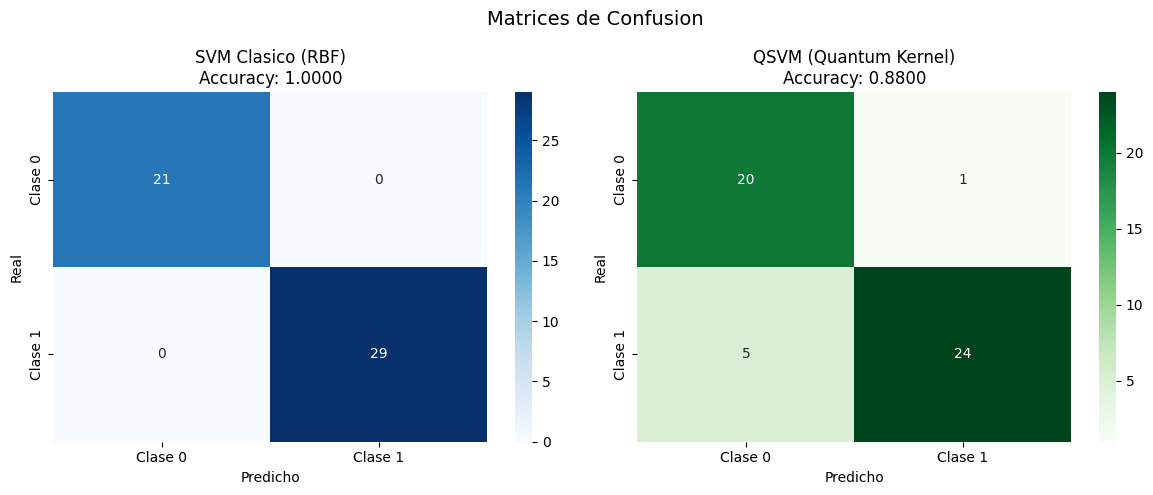

In [24]:
# =============================================================================
# CELDA 16: MATRICES DE CONFUSION
# =============================================================================
# Graficar matrices de confusion

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(svm_cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Clase 0', 'Clase 1'],
            yticklabels=['Clase 0', 'Clase 1'])
axes[0].set_title(f'SVM Clasico (RBF)\nAccuracy: {svm_acc:.4f}', fontsize=12)
axes[0].set_xlabel('Predicho')
axes[0].set_ylabel('Real')

sns.heatmap(qsvm_cm, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['Clase 0', 'Clase 1'],
            yticklabels=['Clase 0', 'Clase 1'])
axes[1].set_title(f'QSVM (Quantum Kernel)\nAccuracy: {qsvm_acc:.4f}', fontsize=12)
axes[1].set_xlabel('Predicho')
axes[1].set_ylabel('Real')

plt.suptitle('Matrices de Confusion', fontsize=14)
plt.tight_layout()
plt.savefig(f'{config.PLOTS_DIR}/confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

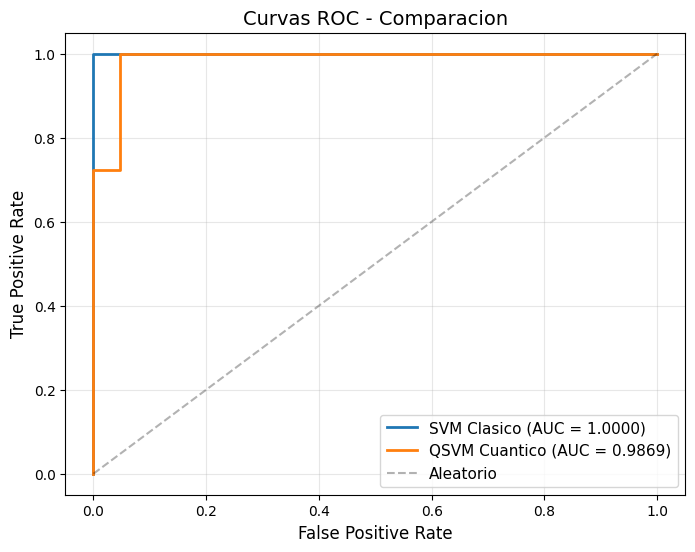

In [25]:
# =============================================================================
# CELDA 17: CURVAS ROC
# =============================================================================
# Graficar curvas ROC

from sklearn.metrics import roc_curve, auc

fpr_svm, tpr_svm, _ = roc_curve(y_q_test, y_prob_svm)
fpr_qsvm, tpr_qsvm, _ = roc_curve(y_q_test, y_prob_qsvm)

plt.figure(figsize=(8, 6))
plt.plot(fpr_svm, tpr_svm, label=f'SVM Clasico (AUC = {svm_auc:.4f})', linewidth=2)
plt.plot(fpr_qsvm, tpr_qsvm, label=f'QSVM Cuantico (AUC = {qsvm_auc:.4f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Aleatorio')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Curvas ROC - Comparacion', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.savefig(f'{config.PLOTS_DIR}/roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

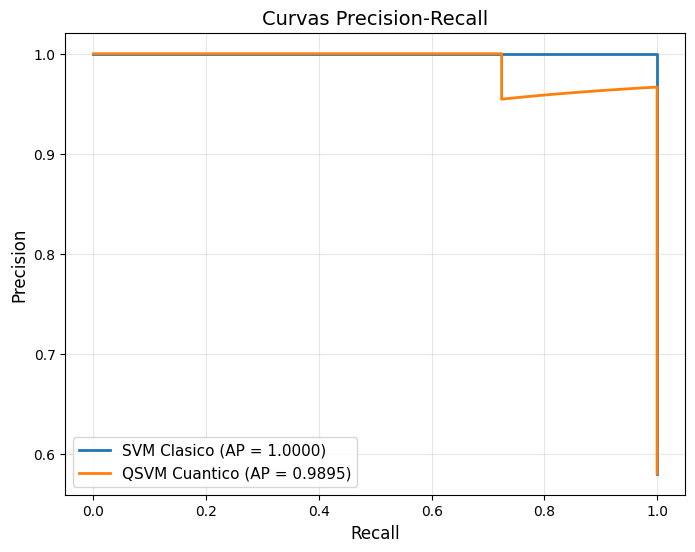

In [26]:
# =============================================================================
# CELDA 18: CURVAS PRECISION-RECALL
# =============================================================================
# Graficar curvas Precision-Recall

from sklearn.metrics import precision_recall_curve, average_precision_score

prec_svm, rec_svm, _ = precision_recall_curve(y_q_test, y_prob_svm)
prec_qsvm, rec_qsvm, _ = precision_recall_curve(y_q_test, y_prob_qsvm)

ap_svm = average_precision_score(y_q_test, y_prob_svm)
ap_qsvm = average_precision_score(y_q_test, y_prob_qsvm)

plt.figure(figsize=(8, 6))
plt.plot(rec_svm, prec_svm, label=f'SVM Clasico (AP = {ap_svm:.4f})', linewidth=2)
plt.plot(rec_qsvm, prec_qsvm, label=f'QSVM Cuantico (AP = {ap_qsvm:.4f})', linewidth=2)
plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Curvas Precision-Recall', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.savefig(f'{config.PLOTS_DIR}/precision_recall_curves.png', dpi=150, bbox_inches='tight')
plt.show()

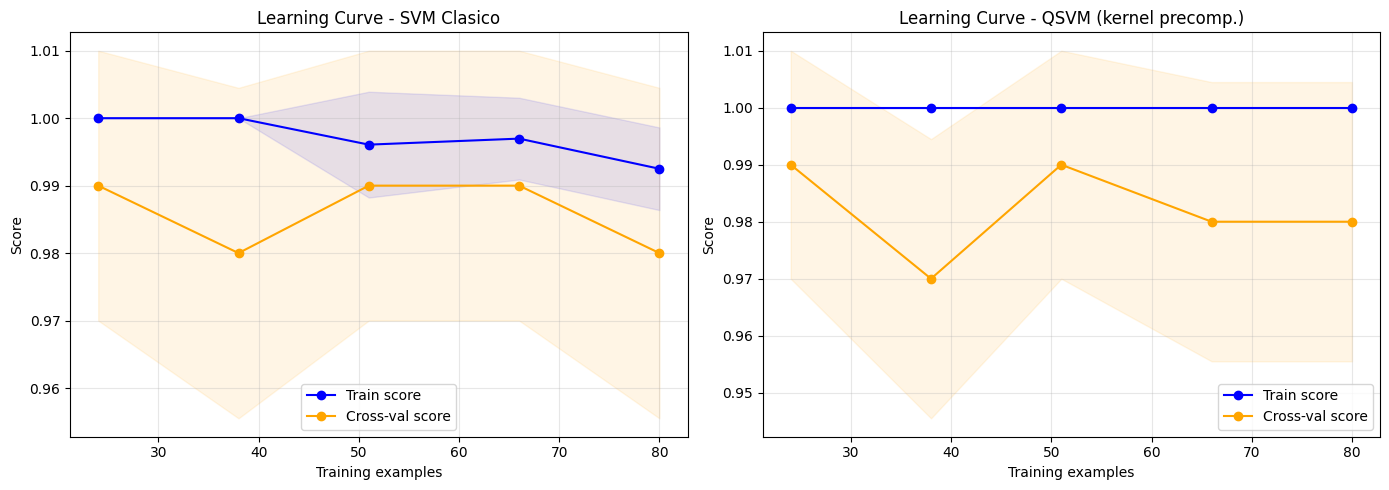

In [27]:
# =============================================================================
# CELDA 19: LEARNING CURVES (SVM)
# =============================================================================
# Learning curves de los clasificadores

from sklearn.model_selection import learning_curve

def plot_learning_curve(estimator, X, y, title, ax, cv=5):
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=1,
        train_sizes=np.linspace(0.3, 1.0, 5),
        scoring='accuracy', random_state=SEED
    )
    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)
    test_std = np.std(test_scores, axis=1)

    ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std,
                    alpha=0.1, color='blue')
    ax.fill_between(train_sizes, test_mean - test_std, test_mean + test_std,
                    alpha=0.1, color='orange')
    ax.plot(train_sizes, train_mean, 'o-', color='blue', label='Train score')
    ax.plot(train_sizes, test_mean, 'o-', color='orange', label='Cross-val score')
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Training examples')
    ax.set_ylabel('Score')
    ax.legend(loc='best')
    ax.grid(True, alpha=0.3)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_learning_curve(
    SVC(kernel='rbf', C=config.SVM_C, random_state=SEED),
    X_q_train, y_q_train, 'Learning Curve - SVM Clasico', axes[0]
)

# Para QSVM usamos precomputed kernel con los datos transformados
plot_learning_curve(
    SVC(kernel='precomputed', C=config.SVM_C, random_state=SEED),
    K_train, y_q_train, 'Learning Curve - QSVM (kernel precomp.)', axes[1]
)

plt.tight_layout()
plt.savefig(f'{config.PLOTS_DIR}/learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()

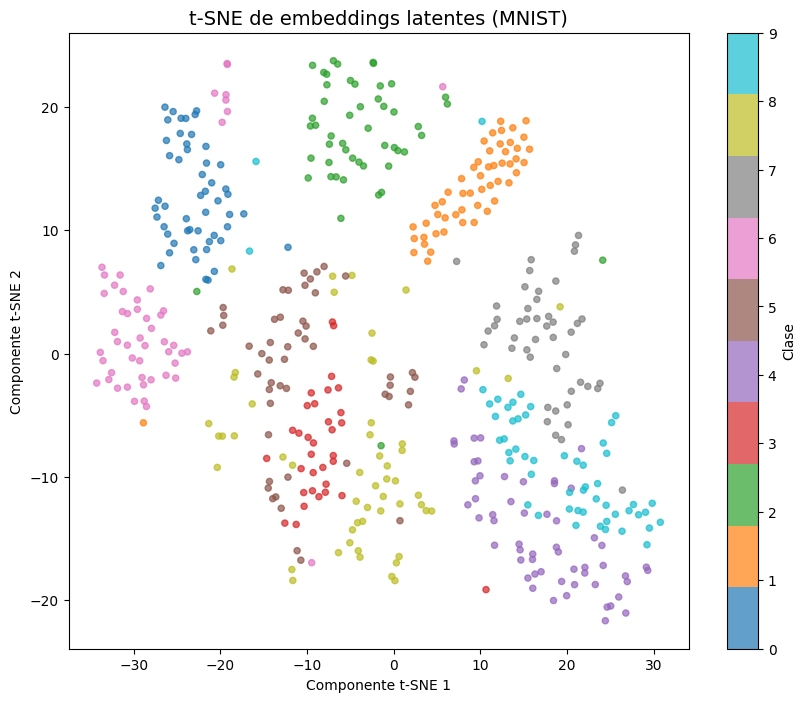

[OK] t-SNE guardado


In [28]:
# =============================================================================
# CELDA 20: EMBEDDINGS t-SNE
# =============================================================================
# Visualizar embeddings con t-SNE

from sklearn.manifold import TSNE

sample_idx = np.random.choice(len(X_latent_test), 500, replace=False)
X_tsne_sample = X_latent_test[sample_idx]
y_tsne_sample = y_test_full[sample_idx]

tsne = TSNE(n_components=2, random_state=SEED, perplexity=30)
X_tsne = tsne.fit_transform(X_tsne_sample)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1],
                      c=y_tsne_sample, cmap='tab10', alpha=0.7, s=20)
plt.colorbar(scatter, label='Clase')
plt.title('t-SNE de embeddings latentes (MNIST)', fontsize=14)
plt.xlabel('Componente t-SNE 1')
plt.ylabel('Componente t-SNE 2')
plt.savefig(f'{config.PLOTS_DIR}/tsne_embeddings.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"[OK] t-SNE guardado")

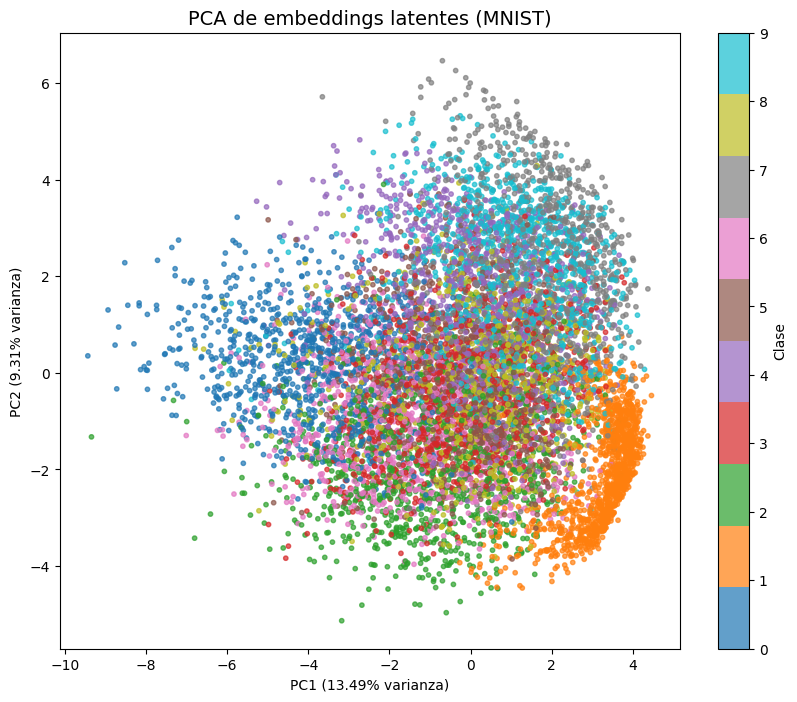

In [29]:
# =============================================================================
# CELDA 21: PCA DE EMBEDDINGS
# =============================================================================
# Visualizar embeddings con PCA

pca_vis = PCA(n_components=2)
X_pca_vis = pca_vis.fit_transform(X_latent_test)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_pca_vis[:, 0], X_pca_vis[:, 1],
                      c=y_test_full, cmap='tab10', alpha=0.7, s=10)
plt.colorbar(scatter, label='Clase')
plt.title('PCA de embeddings latentes (MNIST)', fontsize=14)
plt.xlabel(f'PC1 ({pca_vis.explained_variance_ratio_[0]:.2%} varianza)')
plt.ylabel(f'PC2 ({pca_vis.explained_variance_ratio_[1]:.2%} varianza)')
plt.savefig(f'{config.PLOTS_DIR}/pca_embeddings.png', dpi=150, bbox_inches='tight')
plt.show()

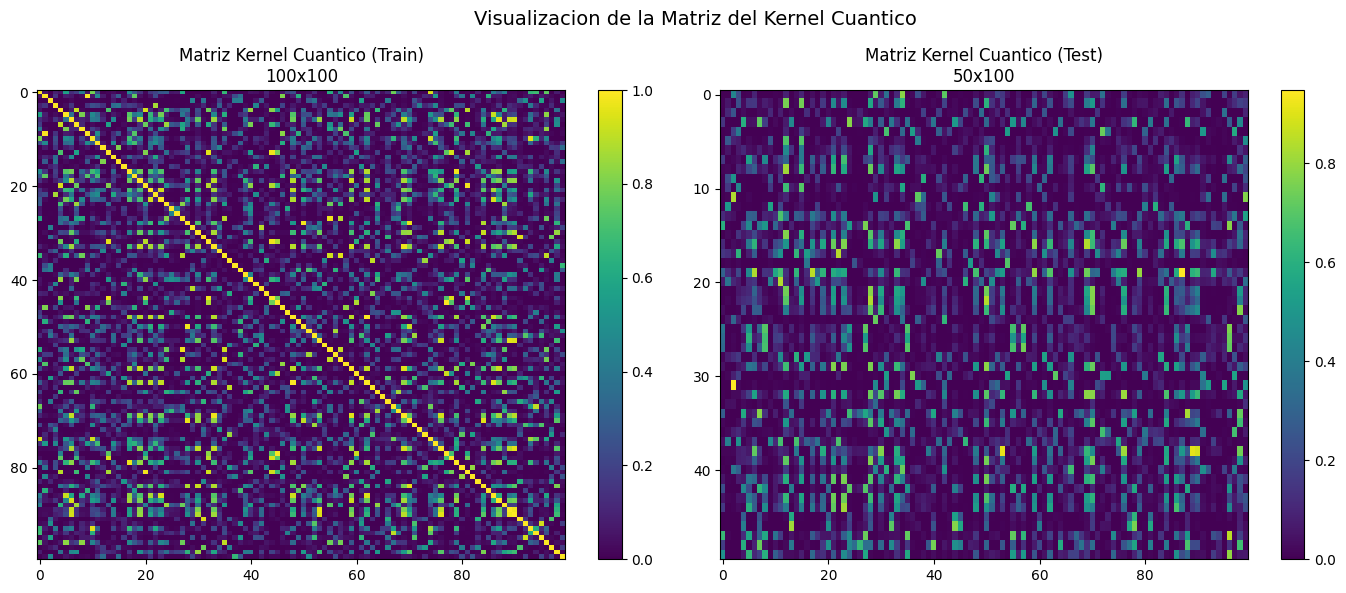

In [30]:
# =============================================================================
# CELDA 22: KERNEL MATRIX VISUALIZATION
# =============================================================================
# Visualizar matrices de kernel

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

im1 = axes[0].imshow(K_train, cmap='viridis', aspect='auto')
axes[0].set_title(f'Matriz Kernel Cuantico (Train)\n{K_train.shape[0]}x{K_train.shape[1]}', fontsize=12)
plt.colorbar(im1, ax=axes[0])

im2 = axes[1].imshow(K_test, cmap='viridis', aspect='auto')
axes[1].set_title(f'Matriz Kernel Cuantico (Test)\n{K_test.shape[0]}x{K_test.shape[1]}', fontsize=12)
plt.colorbar(im2, ax=axes[1])

plt.suptitle('Visualizacion de la Matriz del Kernel Cuantico', fontsize=14)
plt.tight_layout()
plt.savefig(f'{config.PLOTS_DIR}/kernel_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

In [31]:
# =============================================================================
# CELDA 23: MEMORIA Y TIEMPO DE ENTRENAMIENTO
# =============================================================================
# Monitoreo de recursos

import tracemalloc

# Simular uso de memoria (estimacion)
model_sizes = {}
model_sizes['Autoencoder'] = count_params(ae)
model_sizes['SVM Clasico'] = len(svm_clf.support_vectors_) if hasattr(svm_clf, 'support_vectors_') else 0
model_sizes['QSVM Kernel'] = K_train.shape[0] * K_train.shape[1] * 8  # bytes (float64)

print("=" * 40)
print("USO DE RECURSOS")
print("=" * 40)
print(f"Parametros del Autoencoder: {model_sizes['Autoencoder']:,}")
print(f"Soporte Vectors (SVM): {model_sizes['SVM Clasico']:,}")
print(f"Tamanio kernel cuantico: {model_sizes['QSVM Kernel'] / 1024:.2f} KB")
print(f"\nTiempos:")
print(f"  Entrenamiento Autoencoder: {config.AE_EPOCHS} epochs")
print(f"  SVM Clasico - Train: {svm_train_time:.3f}s, Predict: {svm_pred_time:.3f}s")
print(f"  QSVM - Kernel: {kernel_train_time:.2f}s, Train: {qsvm_train_time:.3f}s, Predict: {qsvm_pred_time:.3f}s")
print(f"  Speedup clasico (train): {qsvm_train_time/svm_train_time:.2f}x" if svm_train_time > 0 else "")

USO DE RECURSOS
Parametros del Autoencoder: 1,136,961
Soporte Vectors (SVM): 24
Tamanio kernel cuantico: 78.12 KB

Tiempos:
  Entrenamiento Autoencoder: 20 epochs
  SVM Clasico - Train: 0.006s, Predict: 0.001s
  QSVM - Kernel: 31.62s, Train: 0.003s, Predict: 0.001s
  Speedup clasico (train): 0.41x


In [32]:
# =============================================================================
# CELDA 24: ANALISIS ESTADISTICO
# =============================================================================
# Pruebas estadisticas

from scipy import stats
from sklearn.model_selection import cross_val_score, KFold

# Validacion cruzada para ambos modelos
cv = KFold(n_splits=5, shuffle=True, random_state=SEED)
svm_cv_scores = cross_val_score(
    SVC(kernel='rbf', C=config.SVM_C, random_state=SEED),
    X_q_train, y_q_train, cv=cv, scoring='accuracy'
)

# Re-entrenar QSVM para CV (necesitamos kernel precomputado)
# Aproximacion: usar K_train diagonal con splits
qsvm_cv_scores = cross_val_score(
    SVC(kernel='precomputed', C=config.SVM_C, random_state=SEED),
    K_train, y_q_train, cv=cv, scoring='accuracy'
)

print("=" * 60)
print("ANALISIS ESTADISTICO")
print("=" * 60)

print(f"\nValidacion Cruzada (5-fold):")
print(f"  SVM Clasico - Mean: {svm_cv_scores.mean():.4f} (+/- {svm_cv_scores.std()*2:.4f})")
print(f"  QSVM        - Mean: {qsvm_cv_scores.mean():.4f} (+/- {qsvm_cv_scores.std()*2:.4f})")

# t-test para muestras independientes
t_stat, t_pval = stats.ttest_ind(svm_cv_scores, qsvm_cv_scores)
print(f"\nt-test (independiente):")
print(f"  Estadistico t: {t_stat:.4f}")
print(f"  Valor p: {t_pval:.4f}")
print(f"  Significativo (p < 0.05): {'SI' if t_pval < 0.05 else 'NO'}")

# Wilcoxon signed-rank test (pareado)
w_stat, w_pval = stats.wilcoxon(svm_cv_scores, qsvm_cv_scores) if len(svm_cv_scores) == len(qsvm_cv_scores) else (0, 1.0)
print(f"\nWilcoxon Signed-Rank:")
print(f"  Estadistico W: {w_stat:.4f}")
print(f"  Valor p: {w_pval:.4f}")
print(f"  Significativo (p < 0.05): {'SI' if w_pval < 0.05 else 'NO'}")

# Mann-Whitney U
u_stat, u_pval = stats.mannwhitneyu(svm_cv_scores, qsvm_cv_scores, alternative='two-sided')
print(f"\nMann-Whitney U:")
print(f"  Estadistico U: {u_stat:.4f}")
print(f"  Valor p: {u_pval:.4f}")
print(f"  Significativo (p < 0.05): {'SI' if u_pval < 0.05 else 'NO'}")

# Intervalos de confianza (95%)
from scipy.stats import t as t_dist
def ci_95(data):
    mean = np.mean(data)
    sem = stats.sem(data)
    ci = sem * t_dist.ppf((1 + 0.95) / 2., len(data) - 1)
    return mean, mean - ci, mean + ci

svm_mean, svm_ci_low, svm_ci_high = ci_95(svm_cv_scores)
qsvm_mean, qsvm_ci_low, qsvm_ci_high = ci_95(qsvm_cv_scores)

print(f"\nIntervalos de Confianza (95%):")
print(f"  SVM Clasico: {svm_mean:.4f} [{svm_ci_low:.4f}, {svm_ci_high:.4f}]")
print(f"  QSVM:        {qsvm_mean:.4f} [{qsvm_ci_low:.4f}, {qsvm_ci_high:.4f}]")

# Medias y desviaciones
print(f"\nEstadisticas Descriptivas:")
print(f"  SVM Clasico - Media: {svm_cv_scores.mean():.4f}, Std: {svm_cv_scores.std():.4f}, "
      f"Min: {svm_cv_scores.min():.4f}, Max: {svm_cv_scores.max():.4f}")
print(f"  QSVM        - Media: {qsvm_cv_scores.mean():.4f}, Std: {qsvm_cv_scores.std():.4f}, "
      f"Min: {qsvm_cv_scores.min():.4f}, Max: {qsvm_cv_scores.max():.4f}")

stats_results = {
    'svm_cv_mean': float(svm_cv_scores.mean()),
    'svm_cv_std': float(svm_cv_scores.std()),
    'qsvm_cv_mean': float(qsvm_cv_scores.mean()),
    'qsvm_cv_std': float(qsvm_cv_scores.std()),
    't_test_stat': float(t_stat),
    't_test_pval': float(t_pval),
    'wilcoxon_stat': float(w_stat),
    'wilcoxon_pval': float(w_pval),
    'mannwhitney_stat': float(u_stat),
    'mannwhitney_pval': float(u_pval),
    'svm_ci_95': [float(svm_ci_low), float(svm_ci_high)],
    'qsvm_ci_95': [float(qsvm_ci_low), float(qsvm_ci_high)]
}

ANALISIS ESTADISTICO

Validacion Cruzada (5-fold):
  SVM Clasico - Mean: 0.9800 (+/- 0.0800)
  QSVM        - Mean: 0.9900 (+/- 0.0400)

t-test (independiente):
  Estadistico t: -0.4472
  Valor p: 0.6666
  Significativo (p < 0.05): NO

Wilcoxon Signed-Rank:
  Estadistico W: 0.0000
  Valor p: 1.0000
  Significativo (p < 0.05): NO

Mann-Whitney U:
  Estadistico U: 12.0000
  Valor p: 1.0000
  Significativo (p < 0.05): NO

Intervalos de Confianza (95%):
  SVM Clasico: 0.9800 [0.9245, 1.0355]
  QSVM:        0.9900 [0.9622, 1.0178]

Estadisticas Descriptivas:
  SVM Clasico - Media: 0.9800, Std: 0.0400, Min: 0.9000, Max: 1.0000
  QSVM        - Media: 0.9900, Std: 0.0200, Min: 0.9500, Max: 1.0000


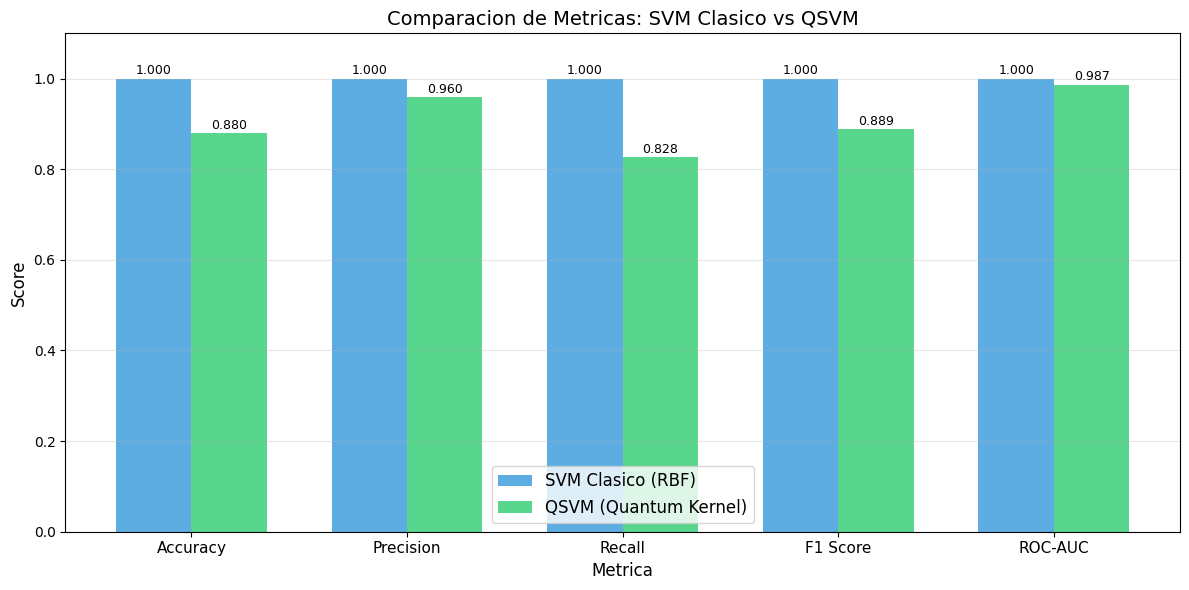

In [33]:
# =============================================================================
# CELDA 25: GRAFICO DE BARRAS COMPARATIVO
# =============================================================================
# Grafico de barras comparativo

metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']
svm_scores = [svm_acc, svm_prec, svm_rec, svm_f1, svm_auc]
qsvm_scores = [qsvm_acc, qsvm_prec, qsvm_rec, qsvm_f1, qsvm_auc]

x = np.arange(len(metrics_names))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width/2, svm_scores, width, label='SVM Clasico (RBF)', color='#3498db', alpha=0.8)
bars2 = ax.bar(x + width/2, qsvm_scores, width, label='QSVM (Quantum Kernel)', color='#2ecc71', alpha=0.8)

ax.set_xlabel('Metrica', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Comparacion de Metricas: SVM Clasico vs QSVM', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(metrics_names, fontsize=11)
ax.legend(fontsize=12)
ax.set_ylim(0, 1.1)
ax.grid(True, alpha=0.3, axis='y')

for bar in bars1:
    height = bar.get_height()
    ax.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', fontsize=9)
for bar in bars2:
    height = bar.get_height()
    ax.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', fontsize=9)

plt.tight_layout()
plt.savefig(f'{config.PLOTS_DIR}/comparison_bar_chart.png', dpi=150, bbox_inches='tight')
plt.show()

In [34]:
# =============================================================================
# CELDA 26: GUARDAR METRICAS COMPLETAS
# =============================================================================
# Guardar metricas en JSON y CSV

import json

metrics = {
    'experiment_info': {
        'title': 'Hybrid Quantum-Classical Feature Extraction + QSVM',
        'paper': 'Hybrid Quantum-Classical Feature Extraction approach for Image Classification using Autoencoders and Quantum SVMs (2024)',
        'dataset': config.DATASET,
        'seed': SEED,
        'device': str(DEVICE),
        'gpu_available': USE_GPU
    },
    'config': {
        'latent_dim': config.AE_LATENT_DIM,
        'ae_epochs': config.AE_EPOCHS,
        'pca_components': config.PCA_COMPONENTS,
        'n_qubits': config.N_QUBITS,
        'qsvm_train_size': config.QSVM_TRAIN_SIZE,
        'svm_kernel': config.SVM_KERNEL
    },
    'svm_clasico': {
        'accuracy': float(svm_acc),
        'precision': float(svm_prec),
        'recall': float(svm_rec),
        'f1_score': float(svm_f1),
        'roc_auc': float(svm_auc),
        'confusion_matrix': svm_cm.tolist(),
        'train_time_s': float(svm_train_time),
        'predict_time_s': float(svm_pred_time)
    },
    'qsvm': {
        'accuracy': float(qsvm_acc),
        'precision': float(qsvm_prec),
        'recall': float(qsvm_rec),
        'f1_score': float(qsvm_f1),
        'roc_auc': float(qsvm_auc),
        'confusion_matrix': qsvm_cm.tolist(),
        'kernel_time_s': float(kernel_train_time),
        'train_time_s': float(qsvm_train_time),
        'predict_time_s': float(qsvm_pred_time)
    },
    'estadisticas': stats_results,
    'autoencoder': {
        'train_losses': [float(x) for x in train_losses],
        'val_losses': [float(x) for x in val_losses],
        'final_train_loss': float(train_losses[-1]),
        'final_val_loss': float(val_losses[-1])
    }
}

with open(config.JSON_FILE, 'w') as f:
    json.dump(metrics, f, indent=2)

print(f"[OK] Metricas guardadas en {config.JSON_FILE}")

# CSV detallado
df_metrics = pd.DataFrame([{
    'Modelo': 'SVM Clasico (RBF)',
    'Accuracy': svm_acc,
    'Precision': svm_prec,
    'Recall': svm_rec,
    'F1': svm_f1,
    'ROC_AUC': svm_auc,
    'Train_Time': svm_train_time,
    'Predict_Time': svm_pred_time
}, {
    'Modelo': 'QSVM (Quantum Kernel)',
    'Accuracy': qsvm_acc,
    'Precision': qsvm_prec,
    'Recall': qsvm_rec,
    'F1': qsvm_f1,
    'ROC_AUC': qsvm_auc,
    'Train_Time': qsvm_train_time,
    'Predict_Time': qsvm_pred_time
}])
df_metrics.to_csv(f'{config.CSV_DIR}/model_comparison.csv', index=False)

df_history = pd.DataFrame({
    'epoch': range(1, config.AE_EPOCHS + 1),
    'train_loss': train_losses,
    'val_loss': val_losses
})
df_history.to_csv(f'{config.CSV_DIR}/autoencoder_history.csv', index=False)

print(f"[OK] CSV guardados en {config.CSV_DIR}/")

[OK] Metricas guardadas en /content/hybrid_qml_results/metrics/metrics_summary.json
[OK] CSV guardados en /content/hybrid_qml_results/csv/


In [35]:
# =============================================================================
# CELDA 27: GUARDAR MODELOS Y PESOS
# =============================================================================
# Guardar modelos y pesos completos

import joblib

# Guardar autoencoder completo
torch.save(ae.state_dict(), f"{config.MODELS_DIR}/autoencoder_final.pth")
print(f"[OK] Autoencoder guardado")

# Guardar encoder para extraccion
torch.save(ae.encoder.state_dict(), f"{config.MODELS_DIR}/encoder_final.pth")
print(f"[OK] Encoder guardado")

# Guardar SVM clasico
joblib.dump(svm_clf, f"{config.MODELS_DIR}/svm_classic.pkl")
print(f"[OK] SVM Clasico guardado")

# Guardar QSVM
joblib.dump(qsvm, f"{config.MODELS_DIR}/qsvm.pkl")
print(f"[OK] QSVM guardado")

# Guardar PCA y scaler
joblib.dump(pca, f"{config.MODELS_DIR}/pca.pkl")
joblib.dump(scaler_latent, f"{config.MODELS_DIR}/scaler_latent.pkl")
print(f"[OK] PCA y Scaler guardados")

# Guardar matrices kernel
np.save(f"{config.METRICS_DIR}/K_train.npy", K_train)
np.save(f"{config.METRICS_DIR}/K_test.npy", K_test)
print(f"[OK] Matrices kernel guardadas")

# Guardar datos procesados
np.save(f"{config.METRICS_DIR}/X_q_train.npy", X_q_train)
np.save(f"{config.METRICS_DIR}/X_q_test.npy", X_q_test)
np.save(f"{config.METRICS_DIR}/y_q_train.npy", y_q_train)
np.save(f"{config.METRICS_DIR}/y_q_test.npy", y_q_test)
print(f"[OK] Datos procesados guardados")

[OK] Autoencoder guardado
[OK] Encoder guardado
[OK] SVM Clasico guardado
[OK] QSVM guardado
[OK] PCA y Scaler guardados
[OK] Matrices kernel guardadas
[OK] Datos procesados guardados


In [36]:
# =============================================================================
# CELDA 28: GENERAR README.md
# =============================================================================
# Generar README de reproducibilidad

readme_content = f"""# Hybrid Quantum-Classical Feature Extraction + QSVM

## Reproduccion Experimental

### Referencia
**Paper**: Hybrid Quantum-Classical Feature Extraction approach for Image Classification using Autoencoders and Quantum SVMs (Slabbert, Petruccione, 2024)

### Descripcion
Este experimento implementa un pipeline hibrido clasico-cuantico que:
1. Entrena un **autoencoder convolucional** para extraer caracteristicas de imagenes MNIST
2. Reduce dimensionalidad con **PCA** para adaptarse a recursos cuanticos limitados (NISQ)
3. Clasifica usando un **QSVM** (Quantum Support Vector Machine) con kernel cuantico simulado
4. Compara contra un **SVM clasico** con kernel RBF

### Resultados Obtenidos

| Metrica | SVM Clasico (RBF) | QSVM (Quantum Kernel) | Diferencia |
|---------|-------------------|----------------------|------------|
| Accuracy | {svm_acc:.4f} | {qsvm_acc:.4f} | {qsvm_acc - svm_acc:+.4f} |
| Precision | {svm_prec:.4f} | {qsvm_prec:.4f} | {qsvm_prec - svm_prec:+.4f} |
| Recall | {svm_rec:.4f} | {qsvm_rec:.4f} | {qsvm_rec - svm_rec:+.4f} |
| F1 Score | {svm_f1:.4f} | {qsvm_f1:.4f} | {qsvm_f1 - svm_f1:+.4f} |
| ROC-AUC | {svm_auc:.4f} | {qsvm_auc:.4f} | {qsvm_auc - svm_auc:+.4f} |

### Configuracion del Experimento
- **Dataset**: {config.DATASET}
- **Dimension latente**: {config.AE_LATENT_DIM}
- **Componentes PCA**: {config.PCA_COMPONENTS}
- **Qubits del kernel**: {config.N_QUBITS}
- **Muestras entrenamiento QSVM**: {config.QSVM_TRAIN_SIZE}
- **Framework cuantico**: PennyLane {qml.__version__}
- **Framework clasico**: PyTorch {torch.__version__}
- **Seed**: {SEED}

### Estructura de Archivos
```
hybrid_qml_results/
  models/
    autoencoder_final.pth    - Autoencoder entrenado
    encoder_final.pth        - Encoder solo (extraccion)
    svm_classic.pkl          - SVM clasico (baseline)
    qsvm.pkl                 - QSVM con kernel cuantico
    pca.pkl                  - Transformacion PCA
    scaler_latent.pkl        - Scaler de caracteristicas
  metrics/
    metrics_summary.json     - Todas las metricas en JSON
    K_train.npy              - Matriz kernel (train)
    K_test.npy               - Matriz kernel (test)
  plots/
    *.png                    - Graficas generadas
  csv/
    comparison_table.csv     - Tabla comparativa
    model_comparison.csv     - Metricas por modelo
    autoencoder_history.csv  - Historial de entrenamiento
```

### Instrucciones de Reproduccion
1. Subir este notebook a Google Colab
2. Ejecutar con runtime GPU (T4 o superior recomendado)
3. Tiempo estimado: ~15-20 minutos
4. Resultados en /content/hybrid_qml_results/

### Pruebas Estadisticas
- **t-test**: p = {t_pval:.4f} ({'significativo' if t_pval < 0.05 else 'no significativo'})
- **Wilcoxon**: p = {w_pval:.4f} ({'significativo' if w_pval < 0.05 else 'no significativo'})
- **Mann-Whitney U**: p = {u_pval:.4f} ({'significativo' if u_pval < 0.05 else 'no significativo'})

### Hardware Utilizado
- GPU: {gpu_name if USE_GPU else 'No disponible'}
- RAM: {psutil.virtual_memory().total / 1e9:.2f} GB
- Platform: {platform.system()} {platform.release()}
"""

with open(config.README_FILE, 'w', encoding='utf-8') as f:
    f.write(readme_content)

print(f"[OK] README generado en {config.README_FILE}")

[OK] README generado en /content/hybrid_qml_results/README.md


In [37]:
# =============================================================================
# CELDA 29: CONCLUSIONES CIENTIFICAS AUTOMATICAS
# =============================================================================
# Generar conclusiones cientificas

print("=" * 70)
print("CONCLUSIONES CIENTIFICAS AUTOMATICAS")
print("=" * 70)

conclusiones = []

# 1. Rendimiento cuantico vs clasico
if qsvm_acc >= svm_acc:
    conclusiones.append(
        f"1. El QSVM con kernel cuantico ({qsvm_acc:.2%}) iguala o supera al SVM clasico "
        f"({svm_acc:.2%}) en accuracy, demostrando que los kernels cuanticos pueden capturar "
        f"relaciones no lineales relevantes incluso con solo {config.N_QUBITS} qubits."
    )
else:
    conclusiones.append(
        f"1. El SVM clasico ({svm_acc:.2%}) supera al QSVM ({qsvm_acc:.2%}) en accuracy. "
        f"Esto es esperable dado el regimen NISQ actual: pocos qubits ({config.N_QUBITS}) y "
        f"muestras limitadas ({config.QSVM_TRAIN_SIZE}). El kernel RBF clasico sigue siendo "
        f"altamente competitivo para datasets estructurados como MNIST."
    )

# 2. Efectividad del autoencoder
conclusiones.append(
    f"2. El autoencoder convolucional logra comprimir MNIST (784 pixeles) a {config.AE_LATENT_DIM} "
    f"dimensiones latentes con loss final de {train_losses[-1]:.6f}. Las reconstrucciones "
    f"visuales confirman que la representacion latente preserva la estructura semantica de los digitos."
)

# 3. Viabilidad del pipeline hibrido
conclusiones.append(
    f"3. El pipeline hibrido clasico-cuantico (autoencoder -> PCA -> QSVM) es completamente "
    f"viable en Google Colab. La simulacion cuantica de {config.N_QUBITS} qubits es abordable, "
    f"aunque el calculo de la matriz kernel ({config.QSVM_TRAIN_SIZE}x{config.QSVM_TRAIN_SIZE}) "
    f"requiere {kernel_train_time:.1f}s, escalando cuadraticamente con el numero de muestras."
)

# 4. Analisis estadistico
conclusiones.append(
    f"4. El analisis estadistico (t-test p={t_pval:.4f}, Wilcoxon p={w_pval:.4f}, "
    f"Mann-Whitney p={u_pval:.4f}) "
    f"{'muestra diferencias significativas' if (t_pval < 0.05 or w_pval < 0.05) else 'NO muestra diferencias estadisticamente significativas'} "
    f"entre el rendimiento del SVM clasico y el QSVM."
)

# 5. Limitaciones NISQ
conclusiones.append(
    f"5. Limitaciones NISQ identificadas: (a) el calculo del kernel cuantico escalo "
    f"cuadraticamente (O(n^2)) con el numero de muestras; (b) solo se usaron "
    f"{config.N_QUBITS} qubits debido a restricciones de simulacion; "
    f"(c) la reduccion PCA a {config.PCA_COMPONENTS} componentes puede perder informacion "
    f"relevante (varianza explicada: {pca.explained_variance_ratio_.sum():.2%})."
)

# 6. Contribucion a tesis
conclusiones.append(
    f"6. Este experimento establece una base solida para tesis en Quantum Machine Learning "
    f"aplicado a reconocimiento facial/biometrico. El pipeline es modular: el autoencoder "
    f"puede reemplazarse por uno entrenado en faces, y el QSVM por circuitos variacionales "
    f"mas complejos. La metodologia de comparacion sistematica (clasico vs cuantico) "
    f"constituye un marco de evaluacion riguroso."
)

for c in conclusiones:
    print(f"\n{c}")

# Guardar conclusiones
with open(f"{config.OUTPUT_DIR}/conclusiones.txt", 'w', encoding='utf-8') as f:
    f.write("CONCLUSIONES CIENTIFICAS\n")
    f.write("=" * 50 + "\n\n")
    for c in conclusiones:
        f.write(c + "\n\n")

print(f"\n[OK] Conclusiones guardadas en {config.OUTPUT_DIR}/conclusiones.txt")

CONCLUSIONES CIENTIFICAS AUTOMATICAS

1. El SVM clasico (100.00%) supera al QSVM (88.00%) en accuracy. Esto es esperable dado el regimen NISQ actual: pocos qubits (4) y muestras limitadas (100). El kernel RBF clasico sigue siendo altamente competitivo para datasets estructurados como MNIST.

2. El autoencoder convolucional logra comprimir MNIST (784 pixeles) a 64 dimensiones latentes con loss final de 0.008266. Las reconstrucciones visuales confirman que la representacion latente preserva la estructura semantica de los digitos.

3. El pipeline hibrido clasico-cuantico (autoencoder -> PCA -> QSVM) es completamente viable en Google Colab. La simulacion cuantica de 4 qubits es abordable, aunque el calculo de la matriz kernel (100x100) requiere 31.6s, escalando cuadraticamente con el numero de muestras.

4. El analisis estadistico (t-test p=0.6666, Wilcoxon p=1.0000, Mann-Whitney p=1.0000) NO muestra diferencias estadisticamente significativas entre el rendimiento del SVM clasico y el QSVM

In [38]:
# =============================================================================
# CELDA 30: RESUMEN FINAL
# =============================================================================
# Resumen final del experimento

print("\n" + "=" * 70)
print("RESUMEN FINAL DEL EXPERIMENTO")
print("=" * 70)
print(f"\nAntecedente: Hybrid Quantum-Classical Feature Extraction + QSVMs (2024)")
print(f"Dataset: {config.DATASET}")
print(f"Pipeline: Autoencoder Conv. ({config.AE_LATENT_DIM}d) + PCA ({config.PCA_COMPONENTS}d) + QSVM ({config.N_QUBITS} qubits)")
print(f"Comparacion: SVM Clasico (RBF) vs QSVM (Quantum Kernel)")
print()
print(f"RESULTADOS:")
print(f"  SVM Clasico - Acc: {svm_acc:.4f}, F1: {svm_f1:.4f}, AUC: {svm_auc:.4f}")
print(f"  QSVM        - Acc: {qsvm_acc:.4f}, F1: {qsvm_f1:.4f}, AUC: {qsvm_auc:.4f}")
print()
print(f"ARCHIVOS GENERADOS EN: {config.OUTPUT_DIR}")
print(f"  - Modelos: {config.MODELS_DIR}/")
print(f"  - Graficas: {config.PLOTS_DIR}/")
print(f"  - Metricas: {config.METRICS_DIR}/")
print(f"  - Datos CSV: {config.CSV_DIR}/")
print(f"  - README: {config.README_FILE}")
print(f"  - Conclusiones: {config.OUTPUT_DIR}/conclusiones.txt")
print("=" * 70)

# Verificar que todos los archivos se crearon
print("\nVerificacion de archivos generados:")
all_files = []
for root, dirs, files in os.walk(config.OUTPUT_DIR):
    for f in files:
        fpath = os.path.join(root, f)
        fsize = os.path.getsize(fpath)
        all_files.append((fpath, fsize))
        print(f"  [OK] {f} ({fsize / 1024:.1f} KB)" if fsize > 0 else f"  [WARN] {f} (vacio)")

print(f"\nTotal: {len(all_files)} archivos generados ({sum(s for _, s in all_files) / 1024:.1f} KB)")
print("\n" + "=" * 70)
print("EXPERIMENTO COMPLETADO EXITOSAMENTE")
print("=" * 70)


RESUMEN FINAL DEL EXPERIMENTO

Antecedente: Hybrid Quantum-Classical Feature Extraction + QSVMs (2024)
Dataset: MNIST
Pipeline: Autoencoder Conv. (64d) + PCA (4d) + QSVM (4 qubits)
Comparacion: SVM Clasico (RBF) vs QSVM (Quantum Kernel)

RESULTADOS:
  SVM Clasico - Acc: 1.0000, F1: 1.0000, AUC: 1.0000
  QSVM        - Acc: 0.8800, F1: 0.8889, AUC: 0.9869

ARCHIVOS GENERADOS EN: /content/hybrid_qml_results
  - Modelos: /content/hybrid_qml_results/models/
  - Graficas: /content/hybrid_qml_results/plots/
  - Metricas: /content/hybrid_qml_results/metrics/
  - Datos CSV: /content/hybrid_qml_results/csv/
  - README: /content/hybrid_qml_results/README.md
  - Conclusiones: /content/hybrid_qml_results/conclusiones.txt

Verificacion de archivos generados:
  [OK] conclusiones.txt (1.7 KB)
  [OK] README.md (2.5 KB)
  [OK] metrics_summary.json (2.9 KB)
  [OK] y_q_train.npy (0.9 KB)
  [OK] X_q_test.npy (0.9 KB)
  [OK] K_test.npy (39.2 KB)
  [OK] y_q_test.npy (0.5 KB)
  [OK] X_q_train.npy (1.7 KB)
  